# 03 — Models Experimenting (Benchmark)

Objectif : comparer les performances (Accuracy, F1) et les capacités (complexité) de différents modèles Spark ML pour choisir le meilleur pour notre pipeline.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml.classification import LogisticRegression, NaiveBayes, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Fix for Spark/Java compatibility
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"

spark = (
    SparkSession.builder
    .appName("AmazonFoodReviews-Benchmark")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

DATA_PATH = Path("../data/Reviews.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../Reviews.csv")

print("Using dataset:", DATA_PATH.resolve())

Using dataset: C:\Users\lenovo\Desktop\Data Engineering\mini-projest 2\data\Reviews.csv


In [2]:
# Load + label with robust options
df_raw = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True, multiLine=True, escape='"')
df = (
    df_raw.select(
        F.col("Id").cast("long").alias("id"),
        F.col("Score").cast("int").alias("score"),
        F.col("Text").cast("string").alias("text"),
    )
    .filter(F.col("score").isNotNull())
    .na.drop(subset=["score", "text"])
    .withColumn("text", F.lower(F.col("text")))
    .withColumn("text", F.regexp_replace(F.col("text"), r"[^a-z0-9\s]", " "))
    .withColumn("text", F.regexp_replace(F.col("text"), r"\s+", " "))
    .withColumn(
        "sentiment",
        F.when(F.col("score").isin([1, 2]), F.lit("Negative"))
         .when(F.col("score") == 3, F.lit("Neutral"))
         .otherwise(F.lit("Positive"))
    )
)

# Split data (use a smaller sample for faster benchmark if needed, but here we use the full set)
train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)
print(f"Train size: {train_df.count()}, Test size: {test_df.count()}")

Train size: 397827, Test size: 170627


In [3]:
# Feature engineering pipeline
tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern=r"\W+")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="raw_features", numFeatures=10000)
idf = IDF(inputCol="raw_features", outputCol="features")
label_indexer = StringIndexer(inputCol="sentiment", outputCol="label")

def run_benchmark(clf, name: str):
    pipe = Pipeline(stages=[tokenizer, stopwords, hashing_tf, idf, label_indexer, clf])
    model = pipe.fit(train_df)
    pred = model.transform(test_df).cache()

    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    metrics = {
        "Model": name,
        "Accuracy": evaluator.evaluate(pred, {evaluator.metricName: "accuracy"}),
        "F1-Score": evaluator.evaluate(pred, {evaluator.metricName: "f1"}),
    }
    pred.unpersist()
    return metrics

results = []
results.append(run_benchmark(NaiveBayes(), "Naive Bayes"))
results.append(run_benchmark(LogisticRegression(maxIter=10), "Logistic Regression"))
results.append(run_benchmark(RandomForestClassifier(numTrees=20, maxDepth=10), "Random Forest"))

## Model Comparison Results

Comparaison visuelle des performances.

                 Model  Accuracy  F1-Score
0          Naive Bayes  0.753070  0.781835
1  Logistic Regression  0.860813  0.846515
2        Random Forest  0.782215  0.687043


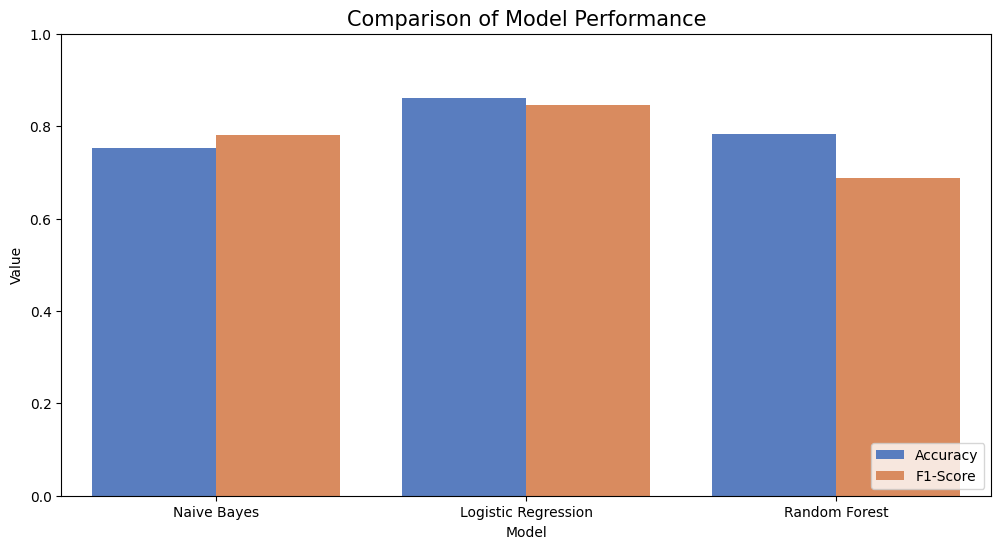

In [4]:
res_df = pd.DataFrame(results)
print(res_df)

plt.figure(figsize=(12, 6))
df_melted = res_df.melt(id_vars="Model", var_name="Metric", value_name="Value")
sns.barplot(x="Model", y="Value", hue="Metric", data=df_melted, palette="muted")
plt.title("Comparison of Model Performance", fontsize=15)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()